#  Ungraded Lab: Numerical Calculations Lab

## Overview
In this lab, you'll explore NumPy's powerful numerical computation capabilities using EngageMetric’s employee data. You'll learn how to perform vectorized operations efficiently and compare their performance with traditional loop-based approaches. Like any good developer's toolkit, your lesson screencasts are valuable resources - keep the lesson video accessible while working through this lab and refer back to it whenever you need a refresher.

## Learning Outcomes
By the end of this lab, you will be able to:
- Create and manipulate NumPy arrays effectively
- Perform vectorized mathematical operations on arrays
- Compare performance between loop-based and vectorized operations
- Apply NumPy functions to real-world data analysis

## Dataset Information
We'll work with EngageMetric’s <b>employee_insights.csv</b> dataset, which contains HR data including:
- Employee satisfaction scores (1-10)
- Overtime hours worked
- Salary information
- Work experience details This dataset will help us perform practical numerical calculations relevant to HR analytics

## Activities
### Activity 1: Basic Array Operations 
Let's start by creating and manipulating NumPy arrays using employee data.

<b>Step 1:</b> Import required libraries and load dataset:

In [1]:
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv('employee_insights.csv')

<b>Step 2: Try It Yourself:</b>  Create arrays from employee data:

In [2]:
# Extract overtime_hours into a NumPy array filling NaN values as 0
overtime = df['overtime_hours'].fillna(0).to_numpy()

# Create an array from satisfaction_score column
satisfaction_score = df ['satisfaction_score'].to_numpy()

print('Overtime array shape: ', overtime.shape)
print('first 5 overtime hours: ', overtime[:5])

print('Satisfaction array shape: ', satisfaction_score.shape)
print('first 5 satisfaction scores: ', satisfaction_score[:5])

Overtime array shape:  (100,)
first 5 overtime hours:  [8.4 8.1 5.2 0.  0.3]
Satisfaction array shape:  (100,)
first 5 satisfaction scores:  [nan nan 10.  5. nan]


<b>Tip:</b> Use .to_numpy() to convert pandas Series to NumPy arrays efficiently.

### Activity 2: Vectorized Calculations
Compare loop-based vs. vectorized operations for calculating overtime cost.

<b>Step 1:</b> Calculate overtime pay using a traditional Python loop:

In [3]:
# Traditional loop approach
def calculate_overtime_loop(hours, rate=20):
    total = 0
    for hour in hours:
        if not np.isnan(hour):
            total += hour * rate
    return total

<b>Step 2: Try It Yourself:</b>  Implement a vectorized NumPy version:

In [4]:
# Create vectorized version
# YOUR CODE HERE
def calculate_overtime_numpy(hours, rate = 20):
    return np.where(np.isnan(hours), 0, hours * rate)
    

<b>Tip:</b> Use NumPy’s array operations.

<b>Test Your Work:</b>

In [5]:
# Compare results and timing of both approaches
import time

# Test loop version
start_time = time.time()
loop_result = calculate_overtime_loop(overtime)
loop_time = time.time() - start_time
print(f"Loop method took {loop_time:.4f} seconds")
print(loop_result)
# Test your vectorized version
# YOUR CODE HERE
start_time = time.time()
numpy_result = calculate_overtime_numpy(overtime)
loop_time = time.time() - start_time
print(f"numpy method took {loop_time:.4f} seconds")
print(numpy_result.sum())

Loop method took 0.0001 seconds
7866.0
numpy method took 0.0001 seconds
7866.0


### Activity 3: Statistical Operations 
Apply NumPy's statistical functions to analyze employee metrics.

<b>Step 1:</b> Calculate basic statistics:

In [12]:
# Get satisfaction score statistics
satisfaction = df['satisfaction_score'].to_numpy()
print(f"Mean satisfaction: {np.nanmean(satisfaction):.2f}")

Mean satisfaction: 5.57


<b>Step 2: Try It Yourself:</b> Calculate and display:

- Median satisfaction score
- Standard deviation
- 25th and 75th percentiles

In [11]:
# YOUR CODE HERE
print(f"Mediad satisfaction: {np.nanmedian(satisfaction):.2f}")
print(f"Standard deviation for satisfaction: {np.nanstd(satisfaction):.2f}")
p25, p75 = np.nanpercentile(satisfaction, [25, 75])
print(f"25th percentile (Q1): {p25:.2f}")
print(f"75th percentile (Q3): {p75:.2f}")


Mediad satisfaction: 6.00
Standard deviation for satisfaction: 2.89
25th percentile (Q1): 3.00
75th percentile (Q3): 8.00


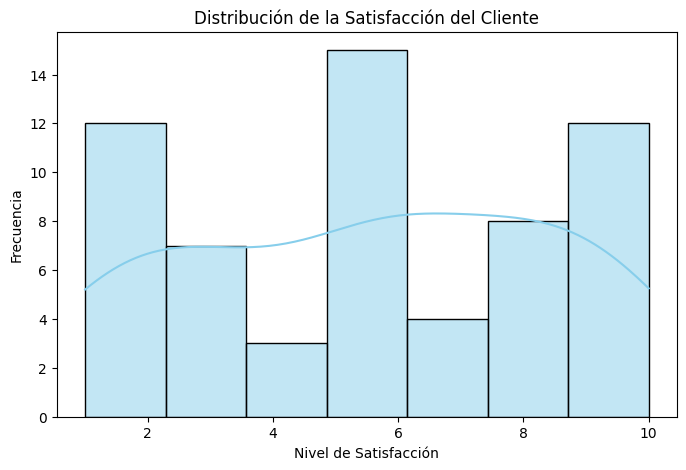

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['satisfaction_score'], kde=True, color='skyblue')
plt.title('Distribución de la Satisfacción del Cliente')
plt.xlabel('Nivel de Satisfacción')
plt.ylabel('Frecuencia')
plt.show()

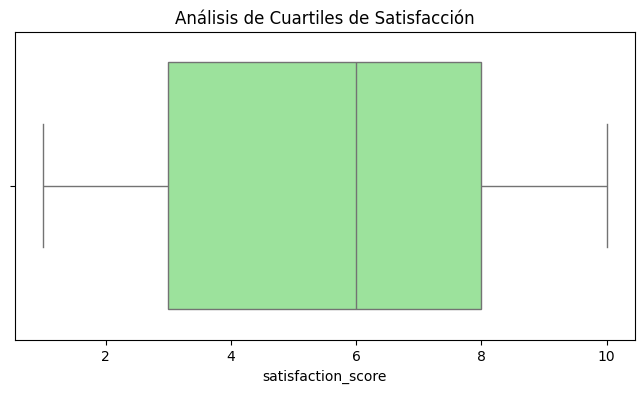

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['satisfaction_score'], color='lightgreen')
plt.title('Análisis de Cuartiles de Satisfacción')
plt.show()

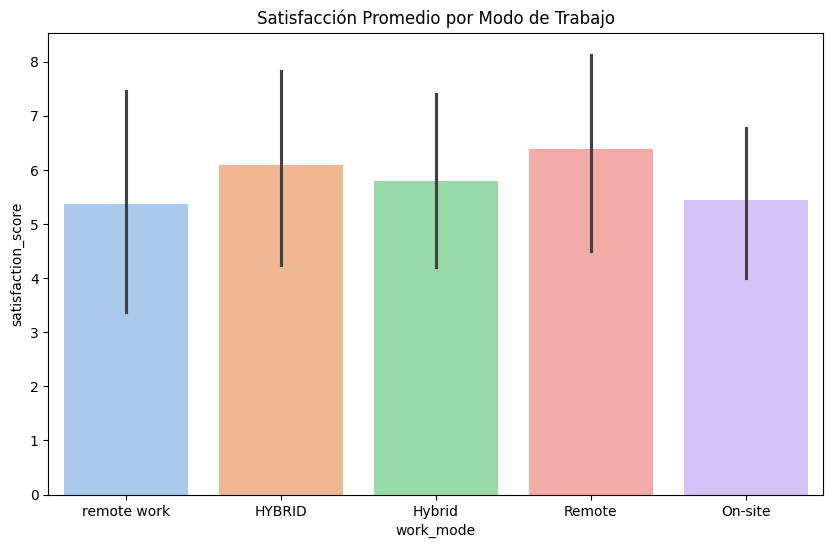

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='work_mode', y='satisfaction_score', data=df, palette='pastel', hue='work_mode', legend=False)
plt.title('Satisfacción Promedio por Modo de Trabajo')
plt.show()

## Success Checklist
- Created and manipulated NumPy arrays successfully
- Implemented both loop-based and vectorized calculations
- Compared performance between approaches
- Calculated meaningful statistics from employee data

## Common Issues & Solutions 
- Problem: NaN values in calculations 
   - Solution: Use np.nanmean() and similar functions for handling missing data
- Problem: Slow performance with loops 
   - Solution: Ensure you're using vectorized operations instead
   
## Summary
Great work completing this lab! You've now mastered fundamental NumPy operations and can efficiently process numerical data using vectorization – skills that are essential for any data scientist working with large datasets. Take these techniques forward as you continue building your data science toolkit, and remember that efficient code isn't just about getting the right answer, but getting it in the most performant way possible.

### Key Points
- NumPy operations are significantly faster than loops
- Vectorization simplifies complex calculations
- NumPy provides efficient tools for statistical analysis

## Solution Code
Stuck on your code or want to check your solution? Here's a complete reference implementation to guide you. This represents just one effective approach—try solving independently first, then use this to overcome obstacles or compare techniques. The solution is provided to help you move forward and explore alternative approaches to achieve the same results. Happy coding!


### Activity 1: Basic Array Operations - Solution Code

In [8]:
import numpy as np
import pandas as pd
import time

# Load the dataset
df = pd.read_csv('employee_insights.csv')

# Create arrays from employee data
overtime = df['overtime_hours'].fillna(0).to_numpy()
satisfaction = df['satisfaction_score'].to_numpy()

# Verify arrays
print("Overtime array shape:", overtime.shape)
print("Sample overtime values:", overtime[:5])

print("\nSatisfaction array shape:", satisfaction.shape)
print("Sample satisfaction values:", satisfaction[:5])

Overtime array shape: (100,)
Sample overtime values: [8.4 8.1 5.2 0.  0.3]

Satisfaction array shape: (100,)
Sample satisfaction values: [nan nan 10.  5. nan]


### Activity 2: Vectorized Calculations - Solution Code

In [9]:
# Loop-based approach
def calculate_overtime_loop(hours, rate=20):
    total = 0
    for hour in hours:
        if not np.isnan(hour):
            total += hour * rate
    return total

# Vectorized approach
def calculate_overtime_vectorized(hours, rate=20):
    return np.nansum(hours * rate)

# Compare performance
start_time = time.time()
loop_result = calculate_overtime_loop(overtime)
loop_time = time.time() - start_time

start_time = time.time()
vectorized_result = calculate_overtime_vectorized(overtime)
vectorized_time = time.time() - start_time

print(f"Loop result: {loop_result:.2f}")
print(f"Loop time: {loop_time:.6f} seconds")
print(f"\nVectorized result: {vectorized_result:.2f}")
print(f"Vectorized time: {vectorized_time:.6f} seconds")
print(f"\nSpeedup factor: {loop_time/vectorized_time:.2f}x")

Loop result: 7866.00
Loop time: 0.000135 seconds

Vectorized result: 7866.00
Vectorized time: 0.000090 seconds

Speedup factor: 1.51x


### Activity 3: Statistical Operations - Solution Code

In [10]:
# Basic statistics for satisfaction scores
print("Satisfaction Score Statistics:")
print(f"Mean: {np.nanmean(satisfaction):.2f}")
print(f"Median: {np.nanmedian(satisfaction):.2f}")
print(f"Standard Deviation: {np.nanstd(satisfaction):.2f}")

# Percentiles
percentiles = np.nanpercentile(satisfaction, [25, 75])
print(f"\nPercentiles:")
print(f"25th percentile: {percentiles[0]:.2f}")
print(f"75th percentile: {percentiles[1]:.2f}")

# Additional statistical analysis
print("\nAdditional Statistics:")
print(f"Min: {np.nanmin(satisfaction):.2f}")
print(f"Max: {np.nanmax(satisfaction):.2f}")
print(f"Range: {np.nanmax(satisfaction) - np.nanmin(satisfaction):.2f}")

Satisfaction Score Statistics:
Mean: 5.57
Median: 6.00
Standard Deviation: 2.89

Percentiles:
25th percentile: 3.00
75th percentile: 8.00

Additional Statistics:
Min: 1.00
Max: 10.00
Range: 9.00
